In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

### 분류

In [2]:
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
# 학습용과 테스트용으로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y,random_state=42)

In [4]:
# 데이터 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 하이퍼 파라미터 목록
param_grid = {
    # 이웃의 개수
    'n_neighbors' : [3,5,7,9,11],
    # 가중치 부여 방식
    'weights' : ['uniform', 'distance'],
    # 거리 측정 방식
    'metric' : ['euclidean', 'manhattan']
}

In [6]:
# 하이퍼 파라미터 튜닝
model = KNeighborsClassifier()
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [7]:
# 최적 모델을 추출하고 예측한다.
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_scaled)
y_pred

array([2, 1, 1, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 1, 2,
       1])

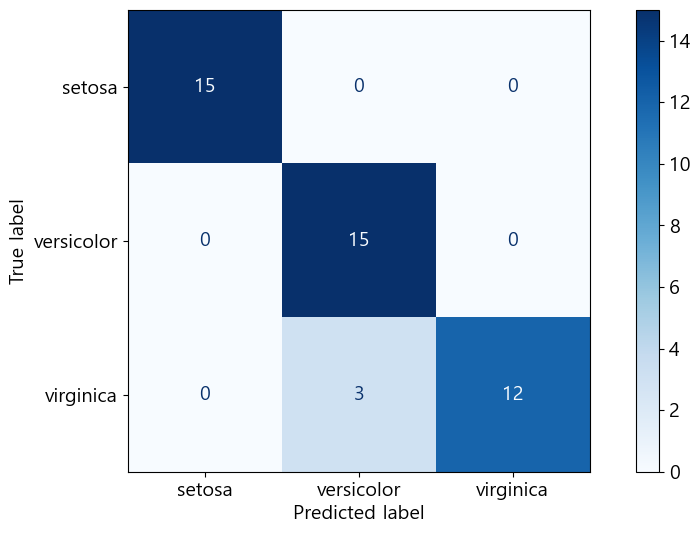

In [8]:
# 혼동행렬을 구한다
cm = confusion_matrix(y_test,y_pred)
# 혼동행렬을 시각화 하기위한 객체를 생성한다.
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=iris.target_names)
# 혼동행렬 시각화
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [9]:
# 평가 점수 확인
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred, average='macro')
recall =recall_score(y_test,y_pred, average='macro')
f1 = f1_score(y_test,y_pred, average='macro')

print(f'최적의 파라미터 : {grid_search.best_params_}')
print(f'accuracy : {accuracy}')
print(f'precision : {precision}')
print(f'recall : {recall}')

최적의 파라미터 : {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
accuracy : 0.9333333333333333
precision : 0.9444444444444445
recall : 0.9333333333333332


### 회귀

In [10]:
from sklearn.datasets import load_diabetes

# 데이터를 불러온다.
diabetes = load_diabetes()
X= diabetes.data
y= diabetes.target

In [11]:
# 데이터를 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# 하이퍼 파라미터 목록
param_grid = {
    # 이웃의 개수
    'n_neighbors' : [3,5,10,20,30],
    # 가중치 부여 방식
    'weights' : ['uniform', 'distance'],
    # 거리 측정 방식
    'metric' : ['euclidean', 'manhattan']
}

In [14]:
# 하이퍼 파라미터 튜닝
model = KNeighborsRegressor()
grid_search = GridSearchCV(model, param_grid=param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [15]:
# 최적 모델을 추출하고 예측한다.
best_reg = grid_search.best_estimator_
y_pred = best_reg.predict(X_test_scaled)
y_pred

array([155.58197147, 152.43147639, 163.12724036, 224.9303559 ,
       162.63688018, 130.59593588, 246.07458453, 183.23252804,
        86.05511782, 124.67047965, 124.03036231, 129.85006767,
       108.2847685 , 189.25119011, 105.33940146, 108.73049177,
       228.39410642, 229.14488218, 153.70613091, 204.78153864,
       177.47620851, 116.47420761,  96.0883961 , 198.49675293,
       140.78928721, 133.78808096, 186.71851168, 156.19357644,
        88.05910761, 143.89526139, 169.84925384, 140.67137668,
       115.94871936, 169.14321971, 165.56026919, 201.82254491,
       110.94324086, 147.69766466, 170.12789725,  86.6608579 ,
       100.97958267, 113.45718585, 150.68108314, 157.66340018,
       168.67359673, 102.21579105, 111.28505134, 110.93032496,
        91.92516054, 143.9237292 , 121.51046179, 109.26409643,
       136.90514419, 108.95977608, 205.00167221, 138.47295614,
       107.71191318, 192.15740987, 102.83614389,  89.86449751,
       172.48633803, 190.39085186,  96.29799064, 111.48

In [16]:
# 0부터 1씩 증가하는 값을 데이터의 개수 만큼 생성한다.
indices = np.arange(len(y_test))
indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88])

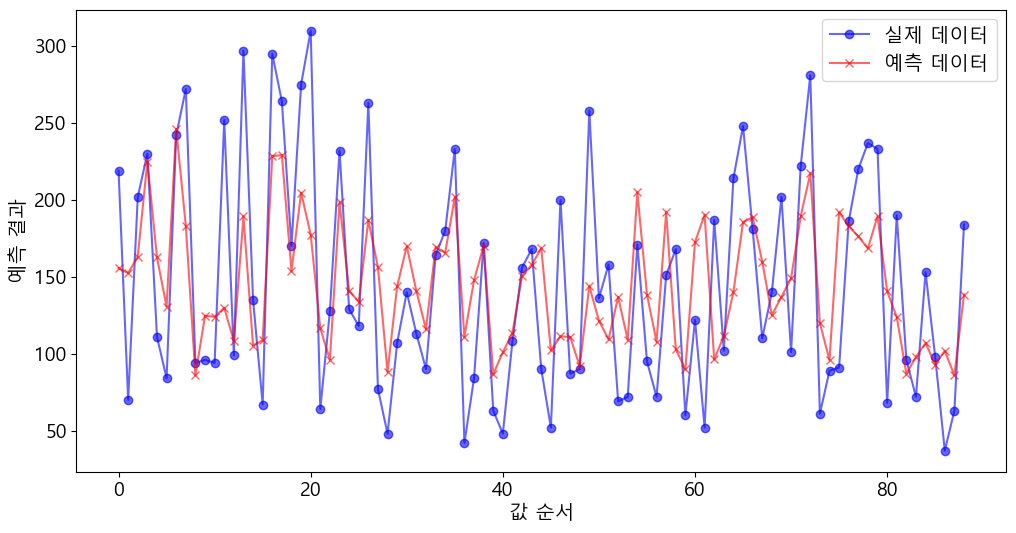

In [17]:
# 실제 데이터
plt.plot(indices, y_test, marker='o', label='실제 데이터', color='blue', alpha=0.6)
# 예측 데이터
plt.plot(indices, y_pred, marker='x', label='예측 데이터', color='red', alpha=0.6)

plt.xlabel('값 순서')
plt.ylabel('예측 결과')

plt.legend()
plt.show()

In [18]:
# 지표 계산 및 결과 출력
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse= root_mean_squared_error(y_test,y_pred)
r2 = best_reg.score(X_test,y_test)

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'MAE : {mse}')
print(f'MSE : {mse}')
print(f'RMSE : {rmse}')
print(f'R2 : {r2}')

최적 파라미터 : {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
MAE : 2988.899429744665
MSE : 2988.899429744665
RMSE : 54.67082795920202
R2 : 0.1404543507611834
